In [102]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import accuracy_score, roc_auc_score, auc, roc_curve, confusion_matrix

In [103]:
df = pd.read_csv("CreditScoring.csv") 

In [104]:
df.head()

,Status,Seniority,Home,Time,Age,Marital,Records,Job,Expenses,Income,Assets,Debt,Amount,Price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,1,0,1,36,26,1,1,1,46,107,0,0,310,910


In [105]:
df.columns = df.columns.str.lower() #stardandize the columns

In [106]:
df.status.value_counts()

status
1    3200
2    1254
0       1
Name: count, dtype: int64

In [107]:
status_values ={
    1: 'ok',
    2: 'default',
    0: 'unknown'
}
df.status = df.status.map(status_values)

home_values ={
    1: 'rent',
    2: 'owner',
    3: 'private',
    4: 'ignore',
    5: 'parents',
    6: 'others',
    0: 'unknown'
}
df.home = df.home.map(home_values)

marital_values ={
    1: 'single',
    2: 'married',
    3: 'widow',
    4: 'seperated',
    5: 'divorced',
    0: 'unknown'
}
df.marital = df.marital.map(marital_values)

records_values ={
    1: 'yes',
    2: 'no',
    0: 'unknown'
}
df.records = df.records.map(records_values)

job_values ={
    1: 'fixed',
    2: 'partime',
    3: 'freelance',
    4: 'others',
    0: 'unknown'
}
df.job = df.job.map(job_values)

In [108]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,yes,freelance,73,129,0,0,800,846
1,ok,17,rent,60,58,widow,yes,fixed,48,131,0,0,1000,1658
2,default,10,owner,36,46,married,no,freelance,90,200,3000,0,2000,2985
3,ok,0,rent,60,24,single,yes,fixed,63,182,2500,0,900,1325
4,ok,0,rent,36,26,single,yes,fixed,46,107,0,0,310,910


In [109]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,763317.0,1060341.0,404382.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,8703625.0,10217569.0,6344253.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3500.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,166.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,99999999.0,99999999.0,99999999.0,5000.0,11140.0


In [110]:
for c in ['income', 'assets', 'debt']:
    df[c] = df[c].replace(to_replace=99999999, value=np.nan)

In [111]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4421.0,4408.0,4437.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,131.0,5403.0,343.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,86.0,11573.0,1246.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3000.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,165.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,959.0,300000.0,30000.0,5000.0,11140.0


In [112]:
df.status.value_counts()

status
ok         3200
default    1254
unknown       1
Name: count, dtype: int64

In [113]:
df = df[df.status != 'unknown'].reset_index(drop=True)

In [114]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
len(df_full_train), len(df_test)

(3563, 891)

In [115]:
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)
len(df_train), len(df_val)

(2672, 891)

In [116]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [117]:
y_train = (df_train.status == 'default').astype('int').values
y_val = (df_val.status == 'default').astype('int').values
y_test = (df_test.status == 'default').astype('int').values

In [118]:
# Remove the target variable from the feature DataFrames
del df_train['status']
del df_val['status']
del df_test['status']

In [119]:
df_train.head()

,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,12,private,24,28,married,yes,fixed,45,102.0,NaN,NaN,700,1229
1,4,others,60,28,married,yes,fixed,60,143.0,0.0,0.0,1150,1630
2,0,owner,60,27,married,yes,fixed,35,295.0,6000.0,0.0,1950,2208
3,6,owner,48,28,married,yes,fixed,45,114.0,3500.0,0.0,650,1255
4,12,owner,36,42,married,yes,freelance,60,0.0,15000.0,0.0,1000,1500


In [120]:
train_dict = df_train.fillna(0).to_dict(orient='records')

In [121]:
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dict)

In [122]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [123]:
val_dict = df_val.fillna(0).to_dict(orient='records')
X_val = dv.transform(val_dict)

In [124]:
y_pred = dt.predict_proba(X_val)[:, 1]

In [125]:
roc_auc_score(y_val, y_pred)

np.float64(0.6589052750992626)

In [126]:
y_pred = dt.predict_proba(X_train)[:, 1]
roc_auc_score(y_train, y_pred)

np.float64(1.0)

In [127]:
dt = DecisionTreeClassifier(max_depth=2)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2)

In [128]:
y_pred = dt.predict_proba(X_train)[:, 1]
auc = roc_auc_score(y_train, y_pred)
print('train: ', auc)

y_pred = dt.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred)
print('val: ', auc)

train:  0.7295775678019526
val:  0.7108180500409655


In [129]:
from sklearn.tree import export_text # use to visualise trees

In [130]:
print(export_text(dt, feature_names=dv.get_feature_names_out()))

|--- income <= 89.50
|   |--- seniority <= 2.50
|   |   |--- class: 1
|   |--- seniority >  2.50
|   |   |--- class: 0
|--- income >  89.50
|   |--- records=no <= 0.50
|   |   |--- class: 0
|   |--- records=no >  0.50
|   |   |--- class: 0



In [131]:
# decision trees parameter tuning
# selecting max depth and min_sample leaf

for d in [1, 2, 3, 4, 5, 6, 10, 15, 20, None]:
    dt = DecisionTreeClassifier(max_depth= d)
    dt.fit(X_train, y_train)
    
    y_pred = dt.predict_proba(X_val)[:,1]
    auc = roc_auc_score(y_val, y_pred)
    
    print('%4s -> %.3f' % (d, auc))
    
    '''the best depth here is 3 to 6 depth, we are going to use the best depth to check for the min sample leaf parameter'''

   1 -> 0.616
   2 -> 0.711
   3 -> 0.752
   4 -> 0.773
   5 -> 0.765
   6 -> 0.730
  10 -> 0.688
  15 -> 0.664
  20 -> 0.647
None -> 0.639


In [132]:
score = []

for d in [3, 4, 5, 6, 10, 15, 20, None]:
    for s in [1, 2, 5, 10, 15, 20, 100, 200, 500]:
        dt = DecisionTreeClassifier(max_depth= d, min_samples_leaf=s)
        dt.fit(X_train, y_train)
    
        y_pred = dt.predict_proba(X_val)[:,1]
        auc = roc_auc_score(y_val, y_pred)
    
        score.append((d, s, auc))

In [133]:
columns=['max_depth', 'min_sample_leaf', 'auc']
df_score = pd.DataFrame(score, columns=columns)
df_score.head()

,max_depth,min_sample_leaf,auc
0,3.0,1,0.751985
1,3.0,2,0.751985
2,3.0,5,0.751985
3,3.0,10,0.751985
4,3.0,15,0.751985


In [134]:
df_score=df_score.sort_values(by= 'auc', ascending=False)
df_score.head()

,max_depth,min_sample_leaf,auc
69,NaN,100,0.788599
51,15.0,100,0.788599
60,20.0,100,0.788599
42,10.0,100,0.788063
31,6.0,15,0.782895


In [135]:
#let make this a pivot table instead

df_score_pivot = df_score.pivot(index='min_sample_leaf', columns=['max_depth'], values=['auc'])
'''min_sample_leaf will be the row, max_depth as the columns and auc are the value,'''

'min_sample_leaf will be the row, max_depth as the columns and auc are the value,'

In [136]:
df_score_pivot.round(3)

auc                                                 
max_depth          NaN   3.0    4.0    5.0    6.0    10.0   15.0   20.0
min_sample_leaf                                                        
1                0.641  0.752  0.773  0.765  0.729  0.674  0.656  0.648
2                0.654  0.752  0.773  0.765  0.740  0.657  0.642  0.656
5                0.717  0.752  0.777  0.774  0.743  0.703  0.706  0.709
10               0.745  0.752  0.778  0.776  0.759  0.753  0.741  0.753
15               0.755  0.752  0.777  0.780  0.783  0.750  0.756  0.755
20               0.763  0.752  0.777  0.779  0.782  0.761  0.763  0.763
100              0.789  0.751  0.777  0.774  0.782  0.788  0.789  0.789
200              0.762  0.748  0.762  0.762  0.762  0.762  0.762  0.762
500              0.687  0.687  0.687  0.687  0.687  0.687  0.687  0.687

<Axes: xlabel='None-max_depth', ylabel='min_sample_leaf'>

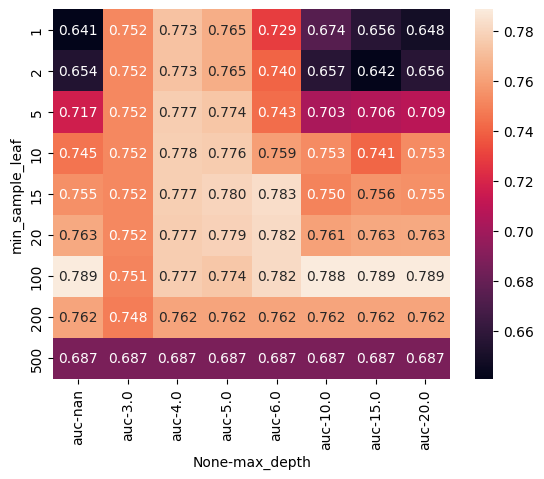

In [137]:
sns.heatmap(df_score_pivot, annot=True, fmt='.3f')

In [138]:
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=15)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, min_samples_leaf=15)

In [139]:
rf = RandomForestClassifier(n_estimators=10, random_state=1)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=10, random_state=1)

In [140]:
y_pred = rf.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

np.float64(0.7689733408961997)

In [141]:
scores = []

for n in range(10, 201, 10):
    rf = RandomForestClassifier(n_estimators=n, random_state=1)
    rf.fit(X_train, y_train)
    
    y_pred = rf.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)
    scores.append((n, auc))

In [142]:
df_scores = pd.DataFrame(scores, columns=['n_estimators', 'auc'])
df_scores.head()

,n_estimators,auc
0,10,0.768973
1,20,0.791898
2,30,0.803876
3,40,0.811335
4,50,0.818091


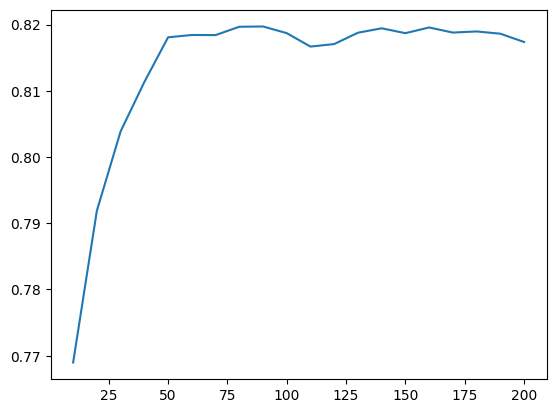

In [143]:
plt.plot(df_scores.n_estimators, df_scores.auc)

In [144]:
scores = []

for d in [5, 10, 15]:
    
    for n in range(10, 201, 10):
        rf = RandomForestClassifier(n_estimators=n, max_depth=d, random_state=1)
        rf.fit(X_train, y_train)
    
        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        scores.append((d, n, auc))

In [145]:
columns = ['max_depth', 'n_estimators', 'auc']
df_scores = pd.DataFrame(scores,columns=columns)
df_scores.head()

,max_depth,n_estimators,auc
0,5,10,0.801172
1,5,20,0.802852
2,5,30,0.808143
3,5,40,0.810692
4,5,50,0.814678


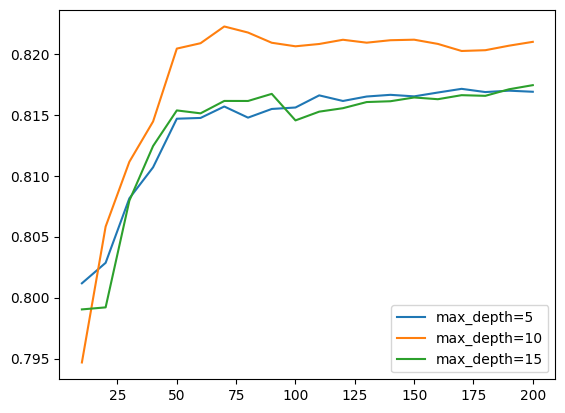

In [146]:
for d in [5, 10, 15]:
    df_subset = df_scores[df_scores.max_depth == d]
    plt.plot(df_subset.n_estimators, df_subset.auc, label='max_depth=%d' % d)
    
plt.legend()

In [147]:
max_depth = 10

In [148]:
scores = []

for s in [1, 3, 5, 10, 50]:
    
    for n in range(10, 201, 10):
        rf = RandomForestClassifier(n_estimators=n, max_depth=max_depth, min_samples_leaf=s, random_state=1)
        rf.fit(X_train, y_train)
    
        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        scores.append((s, n, auc))

In [149]:
columns = ['min_samples_leaf', 'n_estimators', 'auc']
df_scores = pd.DataFrame(scores,columns=columns)
df_scores.head()

,min_samples_leaf,n_estimators,auc
0,1,10,0.794674
1,1,20,0.805823
2,1,30,0.811143
3,1,40,0.814451
4,1,50,0.820432


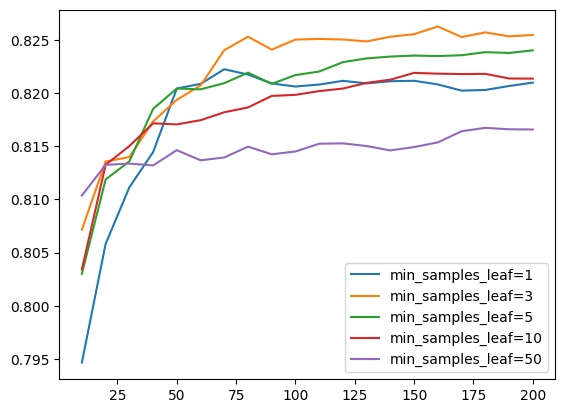

In [150]:
for s in [1, 3, 5, 10, 50]:
    df_subset = df_scores[df_scores.min_samples_leaf == s]
    plt.plot(df_subset.n_estimators, df_subset.auc, label='min_samples_leaf=%d' % s)
    
plt.legend()

In [151]:
min_samples_leaf = 3

In [152]:
rf = RandomForestClassifier(n_estimators=100, max_depth=max_depth, min_samples_leaf=min_samples_leaf, random_state=1, n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=3, n_jobs=-1,
                       random_state=1)

In [153]:
features = dv.get_feature_names_out().tolist()
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)

In [154]:
xgb_params = {
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'binary:logistic',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1, 
}

model = xgb.train(xgb_params, dtrain, num_boost_round=10)

In [155]:
y_pred = model.predict(dval)

In [156]:
roc_auc_score(y_val, y_pred)

np.float64(0.8147349845591478)

In [157]:
watchlist = [(dtrain, 'train'), (dval, 'val')]

In [158]:
%%capture output
xgb_params = {
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'binary:logistic',
    'nthread': 8,
    'eval_metric': 'auc',
    'seed': 1,
    'verbosity': 1, 
}

model = xgb.train(xgb_params, dtrain, num_boost_round=200, verbose_eval= 5, evals=watchlist)

In [159]:
def parse_xgb_output(output):
    results = []
    
    for line in output.stdout.strip().split('\n'):
        it_line, train_line, val_line = line.split('\t')
        
        it = int(it_line.strip('[]'))
        train = float(train_line.split(':')[1])
        val = float(val_line.split(':')[1])
        
        results.append((it, train, val))
        
    columns = ['num_iter', 'train_auc', 'val_auc']
    df_results = pd.DataFrame(results, columns=columns)
    return df_results

In [160]:
df_score = parse_xgb_output(output)
df_score.head()

,num_iter,train_auc,val_auc
0,0,0.86647,0.77479
1,5,0.93236,0.80058
2,10,0.95377,0.81494
3,15,0.96607,0.81365
4,20,0.97411,0.81107


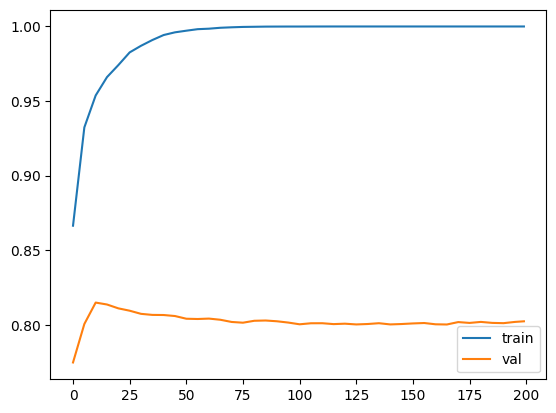

In [161]:
plt.plot(df_score.num_iter, df_score.train_auc, label='train')
plt.plot(df_score.num_iter, df_score.val_auc, label='val')
plt.legend()

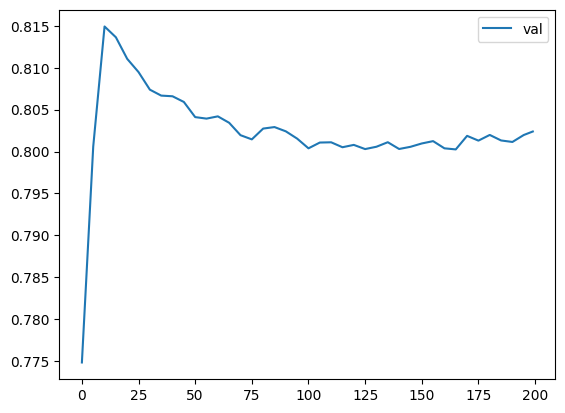

In [162]:
plt.plot(df_score.num_iter, df_score.val_auc, label='val')
plt.legend()

In [187]:
%%capture output
xgb_params = {
    'eta': 0.1,
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'binary:logistic',
    'nthread': 8,
    'eval_metric': 'auc',
    'seed': 1,
    'verbosity': 1, 
}

model = xgb.train(xgb_params, dtrain, num_boost_round=200, verbose_eval= 5, evals=watchlist)

In [180]:
key = 'eta=%s' % (xgb_params['eta'])
scores[key] = parse_xgb_output(output)
key

'eta=1.0'

In [181]:
scores.keys()

dict_keys(['eta=0.3', 'eta=0.1', 'eta=0.01', 'eta=0.05', 'eta=1.0'])

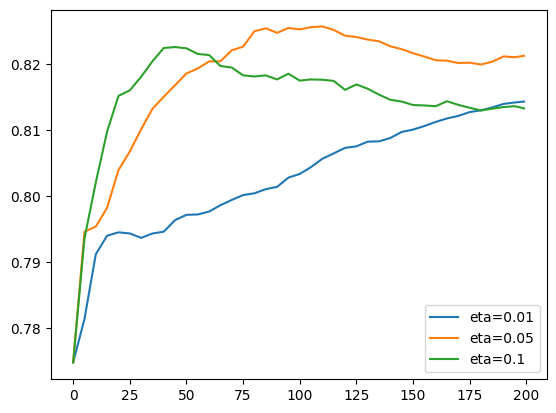

In [186]:
etas = ['eta=0.01', 'eta=0.05', 'eta=0.1']

for eta in etas:
    df_score = scores[eta]
    plt.plot(df_score.num_iter, df_score.val_auc, label=eta)
plt.legend()

In [217]:
%%capture output
xgb_params = {
    'eta': 0.1,
    'max_depth': 10,
    'min_child_weight': 1,
    
    'objective': 'binary:logistic',
    'nthread': 8,
    'eval_metric': 'auc',
    'seed': 1,
    'verbosity': 1, 
}

model = xgb.train(xgb_params, dtrain, num_boost_round=200, verbose_eval= 5, evals=watchlist)

In [226]:
scores = {}

In [244]:
%%capture output
xgb_params = {
    'eta': 0.1,
    'max_depth': 3,
    'min_child_weight': 1,
    
    'objective': 'binary:logistic',
    'nthread': 8,
    'eval_metric': 'auc',
    'seed': 1,
    'verbosity': 1, 
}

model = xgb.train(xgb_params, dtrain, num_boost_round=200, verbose_eval= 5, evals=watchlist)

In [245]:
key = 'min_child_weight=%s' % (xgb_params['min_child_weight'])
scores[key] = parse_xgb_output(output)
key

'min_child_weight=1'

In [246]:
scores.keys()

dict_keys(['min_child_weight=30', 'min_child_weight=10', 'min_child_weight=6', 'min_child_weight=3', 'min_child_weight=1'])

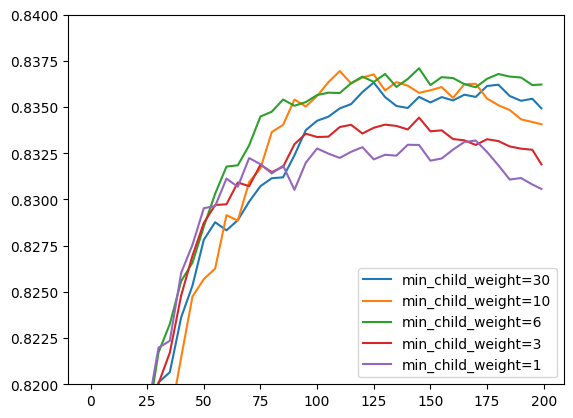

In [247]:
for min_child_weight, df_score in scores.items():
    plt.plot(df_score.num_iter, df_score.val_auc, label=min_child_weight)
plt.ylim(0.82, 0.84)
plt.legend()

In [ ]:
%%capture output
xgb_params = {
    'eta': 0.1,
    'max_depth': 3,
    'min_child_weight': 10,
    
    'objective': 'binary:logistic',
    'nthread': 8,
    'eval_metric': 'auc',
    'seed': 1,
    'verbosity': 1, 
}

model = xgb.train(xgb_params, dtrain, num_boost_round=200, verbose_eval= 5, evals=watchlist)